In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier as KNC
from IPython.display import display

### Déclaration des données

In [18]:
arbres = pd.read_csv("train.csv", index_col = 'ID_ARBRE')
prev = pd.read_csv("prev.csv", index_col = 'ID_ARBRE')

arbres_trie = arbres[["type_sol", "classe_age", "classe_hauteur", "classe_circonference", "port_arbre", "vigueur_pousse", "plaie_collet", "fissure_tronc", "plaie_tronc", "fissure_houppier", "bois_mort_houppier", "plaie_houppier", "esperance_maintien"]]
y = arbres[["classification_diagnostic"]]

In [30]:
display(arbres_trie.head(5))
display(y.head(2))

,type_sol,classe_age,classe_hauteur,classe_circonference,port_arbre,vigueur_pousse,plaie_collet,fissure_tronc,plaie_tronc,fissure_houppier,bois_mort_houppier,plaie_houppier,esperance_maintien
ID_ARBRE,,,,,,,,,,,,,
0,MA,A,H1,C1,R5,P,RCPPL,TPF,TPLS,HPF,HPBM,HPLS,1.0
1,MA,A,H2,C3,R5,P,RCPLS,TFO,TPLNC,HFO,HPBM,HPLNC,2.0
2,GR,A,H1,C2,R5,P,RCPPL,TPF,TPLC,HPF,HPBM,HPLS,1.0
3,Gr,A,H2,C3,R5,P,RCPLC,TPF,TPLC,HPF,HPBM,HPLS,1.0
4,MA,JA,H1,C1,L,P,RCPPL,TPF,TPLS,HPF,HPBM,HPPL,1.0


,classification_diagnostic
ID_ARBRE,
0,C1
1,C4


### Fonction des Distances

In [37]:
# La fonction prend deux NP arrays de même taille
def distance_euclidienne(v1, v2):
    return np.sqrt(np.sum((v1 - v2)**2))

In [39]:
distance_euclidienne(np.array([2, 2]), np.array([1, 7]))

5.0990195135927845

In [41]:
# La fonction prend deux NP arrays de même taille
def distance_manhattan(v1, v2):
    return np.sum(np.abs((v1 - v2)))

### Encodage des données du dataset "arbres"

In [46]:
preprocesseur = ColumnTransformer(
    transformers = [
    ('ord', OrdinalEncoder(), ["type_sol", "classe_age", "classe_hauteur", "classe_circonference", "port_arbre", "vigueur_pousse", "plaie_collet", "fissure_tronc", "plaie_tronc", "fissure_houppier", "bois_mort_houppier", "plaie_houppier", "esperance_maintien"])
    ],
    remainder = "passthrough"
)

arbres_encode = preprocesseur.fit_transform(arbres_trie)
noms_colonnes = preprocesseur.get_feature_names_out()
arbres_encode = pd.DataFrame(arbres_encode, columns = noms_colonnes)
arbres_encode.head(5)

,ord__type_sol,ord__classe_age,ord__classe_hauteur,ord__classe_circonference,ord__port_arbre,ord__vigueur_pousse,ord__plaie_collet,ord__fissure_tronc,ord__plaie_tronc,ord__fissure_houppier,ord__bois_mort_houppier,ord__plaie_houppier,ord__esperance_maintien
0,4.0,0.0,0.0,0.0,2.0,2.0,6.0,2.0,3.0,2.0,2.0,2.0,0.0
1,4.0,0.0,1.0,2.0,2.0,2.0,5.0,1.0,2.0,1.0,2.0,1.0,1.0
2,2.0,0.0,0.0,1.0,2.0,2.0,6.0,2.0,0.0,2.0,2.0,2.0,0.0
3,3.0,0.0,1.0,2.0,2.0,2.0,1.0,2.0,0.0,2.0,2.0,2.0,0.0
4,4.0,3.0,0.0,0.0,1.0,2.0,6.0,2.0,3.0,2.0,2.0,3.0,0.0


### Normalisation & Standardisation

In [12]:
std = StandardScaler()
arbres_encode_std = std.fit_transform(arbres_encode)
arbres_encode_std = pd.DataFrame(arbres_encode_std, columns = noms_colonnes)

In [13]:
mms = MinMaxScaler()
arbres_encode_mms = mms.fit_transform(arbres_encode)
arbres_encode_mms = pd.DataFrame(arbres_encode_mms, columns = noms_colonnes)

In [14]:
print("StandardScaler ")
display(arbres_encode_std.head(3))
print("MinMaxScaler ")
display(arbres_encode_mms.head(3))

StandardScaler 


,ord__type_sol,ord__classe_age,ord__classe_hauteur,ord__classe_circonference,ord__port_arbre,ord__vigueur_pousse,ord__plaie_collet,ord__fissure_tronc,ord__plaie_tronc,ord__fissure_houppier,ord__bois_mort_houppier,ord__plaie_houppier,ord__esperance_maintien
0,0.355789,-0.934012,-0.938643,-0.936901,-0.177616,-0.11238,0.638257,0.071641,0.395376,0.070186,0.199565,-0.275350,-0.567303
1,0.355789,-0.934012,0.464164,1.525293,-0.177616,-0.11238,0.038582,-7.722887,-0.395376,-9.475142,0.199565,-2.327275,0.975762
2,-1.230682,-0.934012,-0.938643,0.294196,-0.177616,-0.11238,0.638257,0.071641,-1.976878,0.070186,0.199565,-0.275350,-0.567303


MinMaxScaler 


,ord__type_sol,ord__classe_age,ord__classe_hauteur,ord__classe_circonference,ord__port_arbre,ord__vigueur_pousse,ord__plaie_collet,ord__fissure_tronc,ord__plaie_tronc,ord__fissure_houppier,ord__bois_mort_houppier,ord__plaie_houppier,ord__esperance_maintien
0,0.571429,0.0,0.00,0.000000,0.666667,0.666667,1.000000,1.0,0.6,1.0,1.0,0.50,0.000000
1,0.571429,0.0,0.25,0.333333,0.666667,0.666667,0.833333,0.5,0.4,0.5,1.0,0.25,0.333333
2,0.285714,0.0,0.00,0.166667,0.666667,0.666667,1.000000,1.0,0.0,1.0,1.0,0.50,0.000000


### Classifieurs K-NN

In [17]:
def classifieur(X_values, df_encode, y, k_voisins):
    kpp = np.argsort([distance_euclidienne(X_values, df_encode.iloc[i]) for i in range(0, len(df_encode))])[0:k_voisins]
    k_classes = [y.iloc[i] for i in kpp]
    value, count = np.unique(k_classes, return_counts = True)
    return value[np.argmax(count)]

In [18]:
def classifieur_direct(X_to_predict, df_encode_train, y_train, k_voisins):
    len_df_encode = len(df_encode_train) #longueur du train_set.
    y_array = y_train.to_numpy() # version numpy du Pandas DataFrame y_train.
    X_values = X_to_predict.to_numpy()
    df_encode = df_encode_train.to_numpy()
    
    predictions = []
    for line in range(len(X_values)):
        distances_line = [distance_euclidienne(X_values[line], df_encode[i]) for i in range(0, len_df_encode)]
        kpp = np.argsort(distances_line)[0:k_voisins] #contient les indices des K-plus-proches distances/voisins
        
        # y_array[kpp] = vecteur contenant les k-plus-proches classes.
        # value = np.unique(y_array) et count = le nombre d'occurences des k-plus-proches classes. Une sorte de value_counts() de y_array[kpp].
        value, count = np.unique(y_array[kpp], return_counts = True)
        # np.argmax(count) contient l'inxex de l'élément qui apparait le plus.
        #On cherche dans value l'élément ayant le plus grand nb d'occurences grâce à np.argmax(count)
        predictions.append(value[np.argmax(count)])
    return predictions

#Prend plus de temps que classifieur classique (quelques secondes d'écart)

### Divisions en X_train, X_test, Y_train, Y_test

In [34]:
X_train, X_test, Y_train, Y_test = train_test_split(arbres_encode_std, y, test_size=0.20, random_state=None)

In [36]:
X_train.head()

,ord__type_sol,ord__classe_age,ord__classe_hauteur,ord__classe_circonference,ord__port_arbre,ord__vigueur_pousse,ord__plaie_collet,ord__fissure_tronc,ord__plaie_tronc,ord__fissure_houppier,ord__bois_mort_houppier,ord__plaie_houppier,ord__esperance_maintien
417,-0.437446,-0.934012,3.269779,1.525293,-1.538505,-0.11238,0.638257,0.071641,0.395376,0.070186,0.199565,-0.27535,-0.567303
81,-2.023917,-0.934012,3.269779,0.294196,-1.538505,-0.11238,0.638257,0.071641,0.395376,0.070186,0.199565,-0.27535,-0.567303
184,-0.437446,-0.934012,0.464164,0.294196,-0.177616,-0.11238,-2.360119,0.071641,-1.976878,0.070186,0.199565,-0.27535,-0.567303
496,-0.437446,-0.934012,3.269779,1.525293,-1.538505,-0.11238,0.638257,0.071641,0.395376,0.070186,0.199565,-0.27535,-0.567303
159,0.355789,-0.934012,0.464164,1.525293,-0.177616,-0.11238,0.038582,0.071641,0.395376,0.070186,0.199565,-0.27535,0.975762


In [38]:
print("X_train :")
display(X_train.head(2))
print("X_test :")
display(X_test.head(2))

X_train :


,ord__type_sol,ord__classe_age,ord__classe_hauteur,ord__classe_circonference,ord__port_arbre,ord__vigueur_pousse,ord__plaie_collet,ord__fissure_tronc,ord__plaie_tronc,ord__fissure_houppier,ord__bois_mort_houppier,ord__plaie_houppier,ord__esperance_maintien
417,-0.437446,-0.934012,3.269779,1.525293,-1.538505,-0.11238,0.638257,0.071641,0.395376,0.070186,0.199565,-0.27535,-0.567303
81,-2.023917,-0.934012,3.269779,0.294196,-1.538505,-0.11238,0.638257,0.071641,0.395376,0.070186,0.199565,-0.27535,-0.567303


X_test :


,ord__type_sol,ord__classe_age,ord__classe_hauteur,ord__classe_circonference,ord__port_arbre,ord__vigueur_pousse,ord__plaie_collet,ord__fissure_tronc,ord__plaie_tronc,ord__fissure_houppier,ord__bois_mort_houppier,ord__plaie_houppier,ord__esperance_maintien
528,0.355789,-0.934012,0.464164,1.525293,-0.177616,-0.11238,0.038582,0.071641,0.395376,0.070186,0.199565,-0.27535,0.975762
54,-0.437446,1.354739,-0.938643,-0.936901,1.183273,-0.11238,0.038582,0.071641,0.395376,0.070186,0.199565,-0.27535,-0.567303


### Prédiction Test set

In [41]:
predictions_test_set = classifieur_direct(X_test, X_train, Y_train, 5)

In [42]:
predictions_test_set

['C2',
 'C1',
 'C2',
 'C2',
 'C2',
 'C2',
 'C1',
 'C1',
 'C1',
 'C1',
 'C1',
 'C2',
 'C2',
 'C2',
 'C5',
 'C1',
 'C2',
 'C2',
 'C1',
 'C1',
 'C2',
 'C1',
 'C2',
 'C2',
 'C1',
 'C2',
 'C2',
 'C2',
 'C2',
 'C2',
 'C2',
 'C2',
 'C2',
 'C2',
 'C2',
 'C1',
 'C2',
 'C2',
 'C1',
 'C2',
 'C5',
 'C3',
 'C2',
 'C2',
 'C2',
 'C1',
 'C1',
 'C2',
 'C1',
 'C2',
 'C2',
 'C1',
 'C2',
 'C3',
 'C2',
 'C2',
 'C1',
 'C1',
 'C2',
 'C1',
 'C1',
 'C2',
 'C5',
 'C2',
 'C2',
 'C1',
 'C1',
 'C2',
 'C2',
 'C1',
 'C2',
 'C2',
 'C2',
 'C1',
 'C1',
 'C2',
 'C1',
 'C1',
 'C2',
 'C1',
 'C2',
 'C2',
 'C1',
 'C1',
 'C2',
 'C2',
 'C1',
 'C1',
 'C2',
 'C2',
 'C1',
 'C2',
 'C2',
 'C2',
 'C2',
 'C2',
 'C2',
 'C1',
 'C1',
 'C2',
 'C1',
 'C1',
 'C1',
 'C2',
 'C1',
 'C1',
 'C1',
 'C1',
 'C2']

### Taux de réussite

In [46]:
def are(predict, Y):
    erreurs = len([i for i, j in zip(predict, Y.to_numpy().flatten()) if i == j])
    taux = np.round((erreurs / len(Y)) * 100, 5)
    #print(f"Average Classification Accuracy : {taux}%")
    return taux

In [48]:
are(predictions_test_set, Y_test)

77.98165

### Fonctions pour trouver le meilleur nombre de voisins - K

In [51]:
def best_k(x_test, x_train, y_train):
    taux_reussite = 0
    best_k = 0
    best_score = 0
    scores_array = []
    for k in range(1, 20, 1):
        predictions = classifieur_direct(x_test, x_train, y_train, k)
        taux_reussite = are(predictions, Y_test)
        scores_array.append(taux_reussite)
        if taux_reussite > best_score:
            best_score = taux_reussite
            best_k = k
    return best_k, best_score, scores_array

In [53]:
best_k, best_score, scores_array = best_k(X_test, X_train, Y_train)

In [54]:
print("best k : ", best_k)
print("best score : ", best_score)

best k :  1
best score :  82.56881


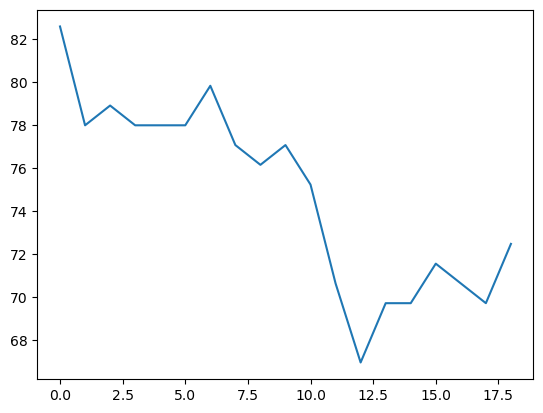

In [55]:
plt.plot(scores_array)

### Encodage et Feature Scaling sur Prev

In [57]:
prev_trie = prev[["type_sol", "classe_age", "classe_hauteur", "classe_circonference", "port_arbre", "vigueur_pousse", "plaie_collet", "fissure_tronc", "plaie_tronc", "fissure_houppier", "bois_mort_houppier", "plaie_houppier", "esperance_maintien"]]
prev_trie.head(3)

,type_sol,classe_age,classe_hauteur,classe_circonference,port_arbre,vigueur_pousse,plaie_collet,fissure_tronc,plaie_tronc,fissure_houppier,bois_mort_houppier,plaie_houppier,esperance_maintien
ID_ARBRE,,,,,,,,,,,,,
559,MA,A,H2,C2,R5,P,RCPLS,TPF,TPLS,HPF,HPBM,HPLNC,2.0
560,Gr,JA,H2,C2,L,P,RCPPL,TPF,TPLS,HPF,HPBM,HPLS,1.0
561,MA,A,H2,C2,R5,P,RCPLS,TPF,TPLS,HPF,HPBM,HPLS,2.0


In [58]:
preprocesseur = ColumnTransformer(
    transformers = [
    ('ord', OrdinalEncoder(), ["type_sol", "classe_age", "classe_hauteur", "classe_circonference", "port_arbre", "vigueur_pousse", "plaie_collet", "fissure_tronc", "plaie_tronc", "fissure_houppier", "bois_mort_houppier", "plaie_houppier", "esperance_maintien"]),
    ],
    remainder = "drop"
)

prev_encode = preprocesseur.fit_transform(prev)
noms_prev_colonnes = preprocesseur.get_feature_names_out()
prev_encode = pd.DataFrame(prev_encode, columns = noms_prev_colonnes)
prev_encode.head(2)

,ord__type_sol,ord__classe_age,ord__classe_hauteur,ord__classe_circonference,ord__port_arbre,ord__vigueur_pousse,ord__plaie_collet,ord__fissure_tronc,ord__plaie_tronc,ord__fissure_houppier,ord__bois_mort_houppier,ord__plaie_houppier,ord__esperance_maintien
0,4.0,0.0,1.0,1.0,2.0,1.0,2.0,1.0,2.0,1.0,1.0,0.0,1.0
1,3.0,2.0,1.0,1.0,1.0,1.0,3.0,1.0,2.0,1.0,1.0,1.0,0.0


In [59]:
prev_encode_mms = mms.fit_transform(prev_encode)
prev_encode_mms = pd.DataFrame(prev_encode_mms, columns = noms_colonnes)
prev_encode_mms.head()

,ord__type_sol,ord__classe_age,ord__classe_hauteur,ord__classe_circonference,ord__port_arbre,ord__vigueur_pousse,ord__plaie_collet,ord__fissure_tronc,ord__plaie_tronc,ord__fissure_houppier,ord__bois_mort_houppier,ord__plaie_houppier,ord__esperance_maintien
0,0.666667,0.0,0.333333,0.333333,0.666667,0.5,0.666667,1.0,0.666667,1.0,1.0,0.0,0.333333
1,0.500000,1.0,0.333333,0.333333,0.333333,0.5,1.000000,1.0,0.666667,1.0,1.0,0.5,0.000000
2,0.666667,0.0,0.333333,0.333333,0.666667,0.5,0.666667,1.0,0.666667,1.0,1.0,0.5,0.333333
3,0.500000,0.5,0.000000,0.000000,0.333333,0.5,1.000000,1.0,1.000000,1.0,1.0,0.5,0.000000
4,1.000000,0.0,0.000000,0.666667,0.000000,0.5,1.000000,1.0,0.333333,1.0,1.0,0.0,0.333333


In [60]:
prev_encode_std = std.fit_transform(prev_encode)
prev_encode_std = pd.DataFrame(prev_encode_std, columns = noms_colonnes)
prev_encode_std.head()

,ord__type_sol,ord__classe_age,ord__classe_hauteur,ord__classe_circonference,ord__port_arbre,ord__vigueur_pousse,ord__plaie_collet,ord__fissure_tronc,ord__plaie_tronc,ord__fissure_houppier,ord__bois_mort_houppier,ord__plaie_houppier,ord__esperance_maintien
0,0.349509,-0.844405,0.572781,0.373611,-0.076640,-0.054113,-0.349348,0.085749,0.397734,0.085749,0.173422,-2.237454,1.093182
1,-0.365158,1.540821,0.572781,0.373611,-1.389103,-0.054113,0.691102,0.085749,0.397734,0.085749,0.173422,-0.233982,-0.483302
2,0.349509,-0.844405,0.572781,0.373611,-0.076640,-0.054113,-0.349348,0.085749,0.397734,0.085749,0.173422,-0.233982,1.093182
3,-0.365158,0.348208,-0.907803,-1.088809,-1.389103,-0.054113,0.691102,0.085749,1.466157,0.085749,0.173422,-0.233982,-0.483302
4,1.778843,-0.844405,-0.907803,1.836032,-2.701566,-0.054113,0.691102,0.085749,-0.670689,0.085749,0.173422,-2.237454,1.093182


### Prédiction du dataset "prev"

In [126]:
previsions_prev_data = classifieur_direct(prev_encode_std, X_train, Y_train, 5)

In [127]:
previsions_prev_data

['C2',
 'C2',
 'C2',
 'C1',
 'C2',
 'C2',
 'C1',
 'C1',
 'C1',
 'C2',
 'C2',
 'C2',
 'C2',
 'C2',
 'C1',
 'C1',
 'C2',
 'C2',
 'C1',
 'C3',
 'C2',
 'C2',
 'C1',
 'C2',
 'C1',
 'C2',
 'C1',
 'C2',
 'C1',
 'C2',
 'C2',
 'C1',
 'C2',
 'C2',
 'C2',
 'C2',
 'C2',
 'C1',
 'C2',
 'C2',
 'C2',
 'C2',
 'C1',
 'C2',
 'C2',
 'C1',
 'C1',
 'C2',
 'C2',
 'C2',
 'C1',
 'C1',
 'C1',
 'C2',
 'C2',
 'C1',
 'C2',
 'C1',
 'C2',
 'C2',
 'C2',
 'C1',
 'C1',
 'C1',
 'C2',
 'C1',
 'C2',
 'C2',
 'C2',
 'C1',
 'C3',
 'C1',
 'C2',
 'C1',
 'C2',
 'C1',
 'C2',
 'C1',
 'C1',
 'C1',
 'C2',
 'C2',
 'C2',
 'C2',
 'C1',
 'C1',
 'C2',
 'C2',
 'C1',
 'C2',
 'C2',
 'C1',
 'C1',
 'C1',
 'C2',
 'C2',
 'C2',
 'C1',
 'C2',
 'C1',
 'C2',
 'C1',
 'C2',
 'C1',
 'C2',
 'C1',
 'C2',
 'C1',
 'C2',
 'C2',
 'C2',
 'C2',
 'C1',
 'C2',
 'C2',
 'C2',
 'C1',
 'C1',
 'C2',
 'C2',
 'C2',
 'C2',
 'C2',
 'C1',
 'C1',
 'C2',
 'C2',
 'C1',
 'C1',
 'C2',
 'C2',
 'C1',
 'C2',
 'C1',
 'C2',
 'C1',
 'C1']

### Cross Validation

In [130]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold, StratifiedKFold

In [152]:
model = KNC(n_neighbors = 5, metric='euclidean')

In [154]:
model.fit(X_train, Y_train["classification_diagnostic"])

KNeighborsClassifier(metric='euclidean')

In [156]:
model.score(X_test, Y_test)

0.908256880733945

In [158]:
previsions_sklearn = model.predict(prev_encode_std)

In [160]:
cv = KFold(5)

In [162]:
cross_validation_train = [cross_val_score(KNC(k), X_train, Y_train["classification_diagnostic"], cv=cv).mean() for k in range(1, 21)]

In [163]:
cross_validation_test = [cross_val_score(KNC(k), X_test, Y_test["classification_diagnostic"], cv=cv).mean() for k in range(1, 21)]

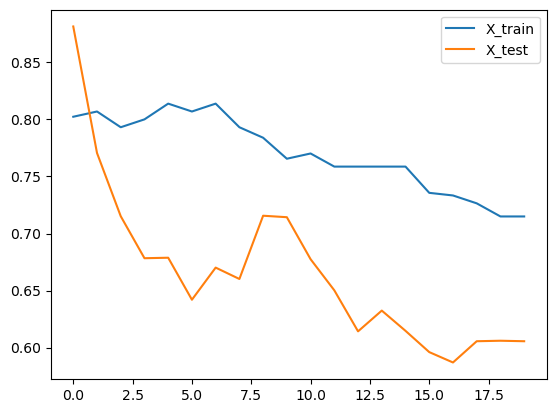

In [164]:
plt.plot(cross_validation_train, label="X_train")
plt.plot(cross_validation_test, label="X_test")
plt.legend()

In [168]:
np.sum(model.predict(X_test) != predictions_test_set)

0

### Submition

In [172]:
sub = pd.DataFrame({'classification_diagnostic': previsions_prev_data})
sub.index.name = "ID_ARBRE"
id_arbre = prev_trie.index  # On récupère l'index chez x2
sub["ID_ARBRE"] = id_arbre  # Ajoute l'index comme colonne
sub = sub.set_index("ID_ARBRE")  # On définie 'ID_ARBRE' en tant qu'index

In [174]:
sub.to_csv("sub_K5_Euclidean.csv")

In [176]:
sub.head()

,classification_diagnostic
ID_ARBRE,
559,C2
560,C2
561,C2
562,C1
563,C2


### Cross Validation from scratch

In [ ]:
len(arbres_encode_std)/5

In [ ]:
folds = np.arange(1, 6, 1)
folds

In [ ]:
arbres_encode_std.iloc[: 108, :].head(2)

In [ ]:
X_train2, X_test2, Y_train2, Y_test2 = train_test_split(arbres_encode_std, y, test_size = 0.2, random_state=None, shuffle=False)

In [ ]:
debut = np.arange(0, 1, 0.25)
fin = np.arange(0.25, 1.25, 0.25)
print("debut : ", debut)
print("fin : ", fin)

In [ ]:
cross_vald = [max([are(classifieur_direct(X_train2.iloc[int(d*len(X_train2)):int(f*len(X_train2)), :], X_train2, Y_train2, k), Y_train2.iloc[int(d*len(X_train2)):int(f*len(X_train2)), :]) for d, f in zip(debut, fin)]) for k in range(1, 20)]

In [ ]:
plt.plot(cross_vald)

In [ ]:
X_train2.to_numpy()[0]